In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os 
os.chdir('/home/nazanin/github/dt-inspired-neuro-fuzzy')

In [3]:
import torch.nn.functional as F
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns 
import numpy as np
import torch.nn as nn
from model.litanfis import LitAnfis, SklearnLitAnfisWrapper
from model.unfis import UNFIS
from model.GIFT import GIFT, SklearnGIFTWrapper, MamdaniGIFT
from model.anfis import ANFIS, SklearnAnfisWrapper
from model.griffin import GRIFFIN, SklearnGRIFFINrapper
from model.giftshift import GIFTSHIFT, SklearnGIFTSHIFTWrapper
import torch
import torch.optim as optim
from torch.optim.lr_scheduler import OneCycleLR
from tests.evaluate import Evaluator

In [4]:
# config

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
train_size = 105
batch_size = 32
random_state = 199

lr = 0.005
max_lr = 0.01
epochs = 100

alpha = 1.0
min_alpha = 0.0
noise_evaluate = True

learning_params = dict(train_size=train_size,
                       batch_size=batch_size,
                       random_state=random_state,
                       lr=lr,
                       max_lr=max_lr,
                       epochs=epochs,
                       alpha=alpha,
                       min_alpha=min_alpha)

In [5]:
# datasetdec

from tests.uci_test import Cryotheraphy, Haberman, Heart, Glass, Segmentaition, Wine, Thyroid, Immunotherapy, Iris, BreastCancer, AdultIncome, BankMarketing, PimaDiabetes, CarEvaluation, Autism, Digits, DNA, MFeat# Synthetic2DGaussianClusters
from tests.class_test import Segmentation, Digits_UCI, Diabetes, BCW, Smoke # TODO try the following datasets Digits DNA
from torch.utils.data import DataLoader


#from tests.uci_test import Autism, CaliforniaHousing, Abalone
#from tests.class_test import Digits, Segmentation, Digits_UCI, Diabetes, BCW, DNA, Smoke, MNIST, ORL


experiment = Immunotherapy(session_id=random_state)
train_dataset = experiment.train_dataset(device)
test_dataset = experiment.test_dataset(device)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=True)

learning_params['train_size'] = experiment.train_numpy()[0].shape[0]
#regression = experiment.target_type == 'regression'
regression = False

,Description,Value
0,Session id,199
1,Target,Result_of_Treatment
2,Target type,Binary
3,Original data shape,"(90, 8)"
4,Transformed data shape,"(90, 8)"
5,Transformed train set shape,"(63, 8)"
6,Transformed test set shape,"(27, 8)"
7,Numeric features,7
8,Preprocess,True
9,Imputation type,iterative


True

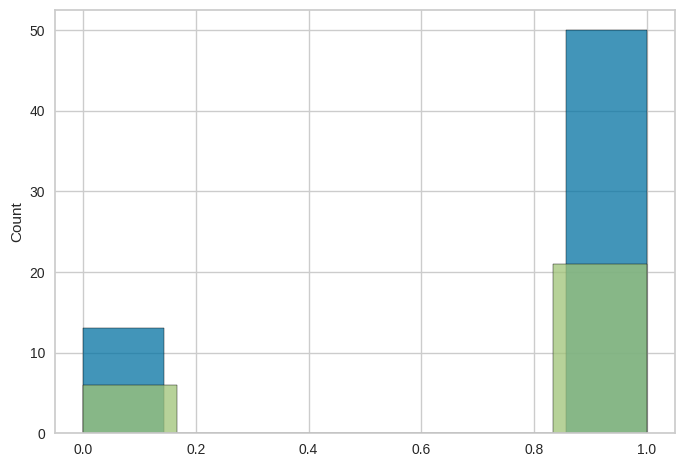

In [6]:
sns.histplot(experiment.train_numpy()[1])
sns.histplot(experiment.test_numpy()[1])

binary = len(np.unique(experiment.train_numpy()[1])) == 2
binary

In [7]:
# Configure evaluator

'''
evaluator = RobustnessEvaluator(
    experiment=experiment,
    model_params_gift={
        'in_features': experiment.train_numpy()[0].shape[1],
        'out_features': len(np.unique(experiment.train_numpy()[1])),
        'rules': 2,
        'drop_out_p': 0.3,
        'binary' : binary
    },
    model_params_litanfis={
        'in_features': experiment.train_numpy()[0].shape[1],
        'out_features': len(np.unique(experiment.train_numpy()[1])),
        'rules': 2,
        'drop_out_p': 0.3,
        'binary': binary
    },
    learning_params={
        'batch_size': 32,
        'lr': 0.005,
        'max_lr': 0.01,
        'epochs': 100,
        'alpha': 1.0,
        'min_alpha': 0.0
    },
    device=device,
    binary=binary,
    noise_levels=[0.0, 0.05, 0.1, 0.15, 0.2, 0.3, 0.4, 0.5],
    n_runs=5,
    random_state=42
)

# Run evaluation
results_df = evaluator.evaluate(verbose=True)

# Plot results
evaluator.plot_robustness_curves(save_path='robustness_curves.png')
evaluator.plot_relative_performance(save_path='relative_performance.png')

# Print detailed report
evaluator.print_detailed_report()

# Get just the best model
best_model, details = evaluator.get_best_model()
print(f"Best model: {best_model}")
print(f"Details: {details}")

'''

'\nevaluator = RobustnessEvaluator(\n    experiment=experiment,\n    model_params_gift={\n        \'in_features\': experiment.train_numpy()[0].shape[1],\n        \'out_features\': len(np.unique(experiment.train_numpy()[1])),\n        \'rules\': 2,\n        \'drop_out_p\': 0.3,\n        \'binary\' : binary\n    },\n    model_params_litanfis={\n        \'in_features\': experiment.train_numpy()[0].shape[1],\n        \'out_features\': len(np.unique(experiment.train_numpy()[1])),\n        \'rules\': 2,\n        \'drop_out_p\': 0.3,\n        \'binary\': binary\n    },\n    learning_params={\n        \'batch_size\': 32,\n        \'lr\': 0.005,\n        \'max_lr\': 0.01,\n        \'epochs\': 100,\n        \'alpha\': 1.0,\n        \'min_alpha\': 0.0\n    },\n    device=device,\n    binary=binary,\n    noise_levels=[0.0, 0.05, 0.1, 0.15, 0.2, 0.3, 0.4, 0.5],\n    n_runs=5,\n    random_state=42\n)\n\n# Run evaluation\nresults_df = evaluator.evaluate(verbose=True)\n\n# Plot results\nevaluator.plot

In [8]:
# prepare the model - modeldec

from train.early_stop import EarlyStopping

model_params = {
    'type': "giftshift", # anfis, unfis, gift, litanfis, gift-mamdani, griffin
    'in_features': experiment.train_numpy()[0].shape[1],
    'out_features': len(np.unique(experiment.train_numpy()[1])),
    'rules': 2,
    'drop_out_p': 0.3,
    'binary' : binary,
    #'rank': 2,
    #'eta':1  
}
zeta = 1.0
rank = 2
eta = 1 
Xi = 1


model_type = model_params.pop('type')

if model_type == "anfis":
    model = ANFIS(**model_params, dtype=torch.float32)
    sk_model = SklearnAnfisWrapper(model, device=device)
elif model_type == "litanfis":
    model = LitAnfis(**model_params, dtype=torch.float32)
    sk_model = SklearnLitAnfisWrapper(model, device=device)
elif model_type == "unfis":
    model = UNFIS(**model_params, dtype=torch.float32)
elif model_type == "gift":
    model = GIFT(**model_params, dtype=torch.float32)
    sk_model = SklearnGIFTWrapper(model, device=device)
elif model_type == "gift-mamdani":
    model = MamdaniGIFT(**model_params, dtype=torch.float32)
    sk_model = SklearnGIFTWrapper(model, device=device)
elif model_type == "griffin":
    model = GRIFFIN(**model_params, dtype=torch.float32, zeta=1, rank=rank, eta=eta, Xi=Xi, regression=regression)
    sk_model = SklearnGRIFFINrapper(model, device=device)
elif model_type == "giftshift":
    model = GIFTSHIFT(**model_params, dtype=torch.float32)
    sk_model = SklearnGIFTSHIFTWrapper(model, device=device)
else:
    raise ValueError("model_type should be one of anfis, unfis, gift")


optimizer = optim.Adam(model.parameters(), lr=lr)

steps_per_epoch=len(train_loader)
scheduler = OneCycleLR(optimizer, max_lr=max_lr,
                       steps_per_epoch=steps_per_epoch, epochs=epochs)

# Early stopping    
early_stopping = EarlyStopping(patience=10, delta=-0.00001)

alpha_decaying = np.power(min_alpha / alpha, (steps_per_epoch * epochs/2))

cos = nn.L1Loss()

if binary:
    cross = nn.BCEWithLogitsLoss()
    
    def criterion(batch_X, batch_y, outputs, reconstructed, alpha):
        return cross(outputs.squeeze(), batch_y.squeeze()) + cos(reconstructed, batch_X) * alpha 

else:
    cross = nn.CrossEntropyLoss()

    def criterion(batch_X, batch_y, outputs, reconstructed, alpha):
        return cross(outputs, batch_y.long()) + cos(reconstructed, batch_X) * alpha 

In [9]:
# train

import random


def set_random_state(seed: int | None = None):
    if seed is None:
        # Generate a random seed from system entropy
        seed = np.random.randint(0, 2**32 - 1)

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    return seed

set_random_state()

history = []

for epoch in range(epochs):
    
    model.train()
    train_loss = 0

    if model_type == 'gift' or model_type == "litanfis":
        stats = model.get_interpretable_params()
        stats["epoch"] = epoch
        history.append(stats)

        if epoch % 10 == 0:
            print(f"Epoch {epoch}: {stats}")

    
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs, reconstructed, entropy = model(batch_X)

        loss = criterion(batch_X, batch_y, outputs, reconstructed, alpha)
        total_loss = loss
        total_loss.backward()
        optimizer.step()
        
        # Step the scheduler, but ignore the "exceeded total steps" error
        try:
            scheduler.step()
        except ValueError as e:
            if "Tried to step" in str(e) and "total steps" in str(e):
                # Reached the end of the scheduled steps; no further adjustments needed
                pass
            else:
                raise
    
    alpha *= alpha_decaying
    train_loss += loss.item() * batch_X.size(0)

    train_loss /= len(train_loader.dataset)
        
    model.eval()
    val_loss = 0
    
    with torch.no_grad():
        for data, target in test_loader:
            output, _, _ = model(data)
            
            if binary:
                loss = cross(output.squeeze(), target.squeeze())
            else:
                loss = cross(output, target.long())

            val_loss += loss.item() * data.size(0)

    val_loss /= len(test_loader.dataset)

    print(
        f'Epoch {epoch+1}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}')

    early_stopping(val_loss, model)
    if early_stopping.early_stop:
        print("Early stopping")
        break
    
early_stopping.load_best_model(model)

Epoch 1, Train Loss: 0.7930, Val Loss: 0.6841
Epoch 2, Train Loss: 0.3375, Val Loss: 0.6826
Epoch 3, Train Loss: 0.3379, Val Loss: 0.6808
Epoch 4, Train Loss: 0.3388, Val Loss: 0.6787
Epoch 5, Train Loss: 0.3358, Val Loss: 0.6760
Epoch 6, Train Loss: 0.3326, Val Loss: 0.6727
Epoch 7, Train Loss: 0.3311, Val Loss: 0.6689
Epoch 8, Train Loss: 0.3319, Val Loss: 0.6641
Epoch 9, Train Loss: 0.3295, Val Loss: 0.6583
Epoch 10, Train Loss: 0.3273, Val Loss: 0.6515
Epoch 11, Train Loss: 0.3260, Val Loss: 0.6436
Epoch 12, Train Loss: 0.3231, Val Loss: 0.6347
Epoch 13, Train Loss: 0.3126, Val Loss: 0.6250
Epoch 14, Train Loss: 0.3108, Val Loss: 0.6139
Epoch 15, Train Loss: 0.3180, Val Loss: 0.6017
Epoch 16, Train Loss: 0.3117, Val Loss: 0.5887
Epoch 17, Train Loss: 0.3008, Val Loss: 0.5751
Epoch 18, Train Loss: 0.2910, Val Loss: 0.5611
Epoch 19, Train Loss: 0.2679, Val Loss: 0.5470
Epoch 20, Train Loss: 0.2747, Val Loss: 0.5323
Epoch 21, Train Loss: 0.2930, Val Loss: 0.5182
Epoch 22, Train Loss: 

In [10]:
%matplotlib inline  
experiment.evaluate_model(sk_model)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

In [11]:
# Evaluate Model: Classification Report, AUC, and Hyperparameters


from sklearn.metrics import classification_report, roc_auc_score
import pprint
import numpy as np

# Get raw labels (might be 1D or one‑hot)
y_train_raw = experiment.train_numpy()[1]
y_test_raw  = experiment.test_numpy()[1]

# Convert to 1D if necessary
if y_train_raw.ndim == 2:
    y_train = np.argmax(y_train_raw, axis=1)
    y_test  = np.argmax(y_test_raw, axis=1)
else:
    y_train = y_train_raw
    y_test  = y_test_raw

# Get predicted probabilities
y_train_proba = sk_model.predict_proba(experiment.train_numpy()[0])
y_test_proba  = sk_model.predict_proba(experiment.test_numpy()[0])

# For binary classification, roc_auc_score expects probability of the positive class
if binary:
    # If probabilities have 2 columns, take the second column (positive class)
    if y_train_proba.shape[1] == 2:
        y_train_proba_bin = y_train_proba[:, 1]
        y_test_proba_bin  = y_test_proba[:, 1]
    else:
        y_train_proba_bin = y_train_proba[:, 0]
        y_test_proba_bin  = y_test_proba[:, 0]
    train_auc = roc_auc_score(y_train, y_train_proba_bin)
    test_auc  = roc_auc_score(y_test,  y_test_proba_bin)
else:
    train_auc = roc_auc_score(y_train, y_train_proba, multi_class='ovr')
    test_auc  = roc_auc_score(y_test,  y_test_proba, multi_class='ovr')

# Build result string
result = ""
result += f'Experiment Result {experiment.__class__.__name__}\n'
result += '------ train ------\n'
result += classification_report(y_train, sk_model.predict(experiment.train_numpy()[0]), digits=4)
result += f'AUC\t{train_auc}\n'
result += '------ test ------\n'
result += classification_report(y_test, sk_model.predict(experiment.test_numpy()[0]), digits=4)
result += f'AUC\t{test_auc}\n'

result += f'{pprint.pformat(model_params)}\n'
result += pprint.pformat(learning_params)

print(result)

Experiment Result Immunotherapy
------ train ------
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000        13
           1     0.7937    1.0000    0.8850        50

    accuracy                         0.7937        63
   macro avg     0.3968    0.5000    0.4425        63
weighted avg     0.6299    0.7937    0.7023        63
AUC	0.7323076923076923
------ test ------
              precision    recall  f1-score   support

           0     1.0000    0.1667    0.2857         6
           1     0.8077    1.0000    0.8936        21

    accuracy                         0.8148        27
   macro avg     0.9038    0.5833    0.5897        27
weighted avg     0.8504    0.8148    0.7585        27
AUC	0.8571428571428571
{'binary': True,
 'drop_out_p': 0.3,
 'in_features': 7,
 'out_features': 2,
 'rules': 2}
{'alpha': 1.0,
 'batch_size': 32,
 'epochs': 100,
 'lr': 0.005,
 'max_lr': 0.01,
 'min_alpha': 0.0,
 'random_state': 199,
 'train_size': 63}


In [12]:
with open(f'results/{model_type}_{experiment.__class__.__name__}_{model_params["rules"]}.txt', mode='w') as f:
    f.write(result)

In [13]:
# plot the membership functions
from model.mf_plot import plot_litanfis_mfs, plot_gift_mfs, plot_gift_param_progress
if model_type == "gift":
    X_train_np, y_train_np = experiment.train_numpy() 
    plot_gift_mfs(model, feature_names=None)


if model_type == 'litanfis':
    X_train_np, y_train_np = experiment.train_numpy()
    plot_litanfis_mfs(model, feature_names=None)


In [14]:
# ROC Curve (Binary or One‑vs‑Rest) with Zoom-in on High Performance
'''import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, RocCurveDisplay
from sklearn.preprocessing import label_binarize

X_test, y_test = experiment.test_numpy()
y_score = sk_model.predict_proba(X_test)

classes = np.unique(y_test)
n_classes = len(classes)

plt.figure(figsize=(8, 8), dpi=200)

# Binary classification
if n_classes == 2:
    # Determine which column(s) to use
    if y_score.shape[1] == 2:
        # Standard case: two columns, second is probability of positive class
        y_score_bin = y_score[:, 1]
    elif y_score.shape[1] == 1:
        # Single column: assume it's probability of the positive class
        y_score_bin = y_score[:, 0]
    else:
        raise ValueError(f"Unexpected y_score shape: {y_score.shape}")

    fpr, tpr, _ = roc_curve(y_test, y_score_bin)
    roc_auc = auc(fpr, tpr)

    RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc,
                    estimator_name='Binary classifier').plot()

# Multiclass classification
else:
    # Binarize labels (One-vs-Rest)
    y_test_bin = label_binarize(y_test, classes=classes)

    for i, cls in enumerate(classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc = auc(fpr, tpr)

        plt.plot(fpr, tpr, label=f"Class {cls} (AUC = {roc_auc:.3f})")

    plt.legend(loc="lower right")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve (One-vs-Rest)")

# Zoom
plt.xlim([0.0, 0.025])
plt.ylim([0.99, 1.0])
plt.grid(True)

plt.show()'''


'import numpy as np\nimport matplotlib.pyplot as plt\nfrom sklearn.metrics import roc_curve, auc, RocCurveDisplay\nfrom sklearn.preprocessing import label_binarize\n\nX_test, y_test = experiment.test_numpy()\ny_score = sk_model.predict_proba(X_test)\n\nclasses = np.unique(y_test)\nn_classes = len(classes)\n\nplt.figure(figsize=(8, 8), dpi=200)\n\n# Binary classification\nif n_classes == 2:\n    # Determine which column(s) to use\n    if y_score.shape[1] == 2:\n        # Standard case: two columns, second is probability of positive class\n        y_score_bin = y_score[:, 1]\n    elif y_score.shape[1] == 1:\n        # Single column: assume it\'s probability of the positive class\n        y_score_bin = y_score[:, 0]\n    else:\n        raise ValueError(f"Unexpected y_score shape: {y_score.shape}")\n\n    fpr, tpr, _ = roc_curve(y_test, y_score_bin)\n    roc_auc = auc(fpr, tpr)\n\n    RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc,\n                    estimator_name=\'Binary classifier

In [15]:
# Import necessary modules
import torch
import numpy as np
from tests.evaluate import Evaluator  # or wherever your Evaluator is located

# Configure device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Set binary classification flag
binary = True  # or False for multi-class

# Define model configurations
model_configs = {
    'GIFT': {
        'model_class': GIFT,
        'wrapper_class': SklearnGIFTWrapper,
        'params': {
            'rules': 2,
            'drop_out_p': 0.3,
        }
    }, 
    'GIFTSHIFT': {
        'model_class': GIFTSHIFT,
        'wrapper_class': SklearnGIFTSHIFTWrapper,
        'params': {
            'rules': 2,
            'drop_out_p': 0.3,
        }
    }
}

# Define learning parameters
learning_params = {
    'batch_size': 32,
    'lr': 0.005,
    'max_lr': 0.01,
    'epochs': 100,
    'alpha': 1.0,
    'min_alpha': 0.0
}

# Create evaluator instance
evaluator = Evaluator(
    experiment=experiment,
    model_configs=model_configs,
    learning_params=learning_params,
    device=device,
    binary=binary,
    noise_levels=[0.0, 0.05, 0.1, 0.15, 0.2, 0.3, 0.4, 0.5],
    n_runs=5,
    random_state=42,  # Set to None for random results each run
    use_noise=False,   # Set to False for clean data only
    noise_type="gaussian"  # or "salt_pepper"
)

# Run evaluation
results_df = evaluator.evaluate(verbose=True)

# Print detailed report
evaluator.print_detailed_report()

# Plot results (only if noise is enabled)
if evaluator.use_noise:
    evaluator.plot_robustness_curves(save_path="robustness_curves.png")
    evaluator.plot_relative_performance(save_path="relative_performance.png")


🔇 NOISE IS DISABLED - Clean data evaluation only


Noise levels:   0%|          | 0/1 [00:00<?, ?it/s]


Testing: CLEAN DATA (σ = 0)

Training GIFT...
  Run 1/5... Acc=0.7407
  Run 2/5... Acc=0.7778
  Run 3/5... Acc=0.7407
  Run 4/5... Acc=0.7037
  Run 5/5... Acc=0.7778

Training GIFTSHIFT...
  Run 1/5... Acc=0.8148
  Run 2/5... Acc=0.7778
  Run 3/5... Acc=0.8148
  Run 4/5... Acc=0.8519
  Run 5/5... 

Noise levels: 100%|██████████| 1/1 [00:02<00:00,  2.76s/it]

Acc=0.7778

MODEL EVALUATION REPORT
Dataset: Immunotherapy
Noise Enabled: False
Number of runs per configuration: 5

📊 PERFORMANCE SUMMARY:
--------------------------------------------------------------------------------
Model           Noise σ    Test Acc ± Std       Test AUC ± Std      
--------------------------------------------------------------------------------
GIFT            Clean      0.7481 ± 0.0277    0.7397 ± 0.0488
GIFTSHIFT       Clean      0.8074 ± 0.0277    0.8333 ± 0.0554

🏆 VERDICT:
--------------------------------------------------------------------------------
✅ BEST MODEL: GIFTSHIFT
📝 Reason: GIFTSHIFT outperforms on clean data: +5.93% accuracy, +9.37% AUC

Detailed criteria comparison:
  • test_accuracy: GIFTSHIFT
  • test_auc: GIFTSHIFT
  • more_stable: GIFTSHIFT
